[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Building dataset...
Preparing models...
Training SimpleRNN...
Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== Test Metrics (lower is better) ===
    Model      MSE    RMSE     MAE   MAPE
      GRU 253.3118 15.9158 11.6179 4.0033
SimpleRNN 334.4593 18.2882 13.8954 4.7799
     LSTM 393.7680 19.8436 14.5556 4.9941


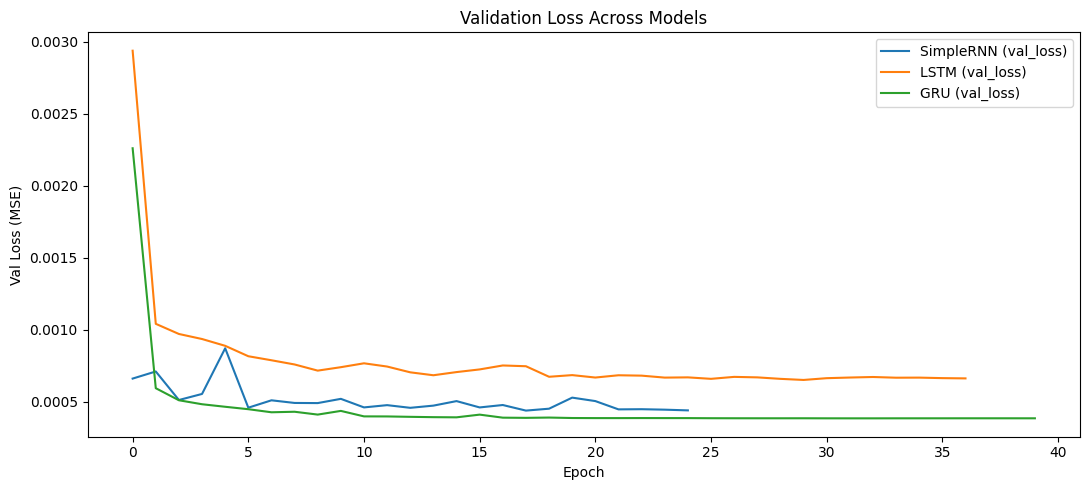

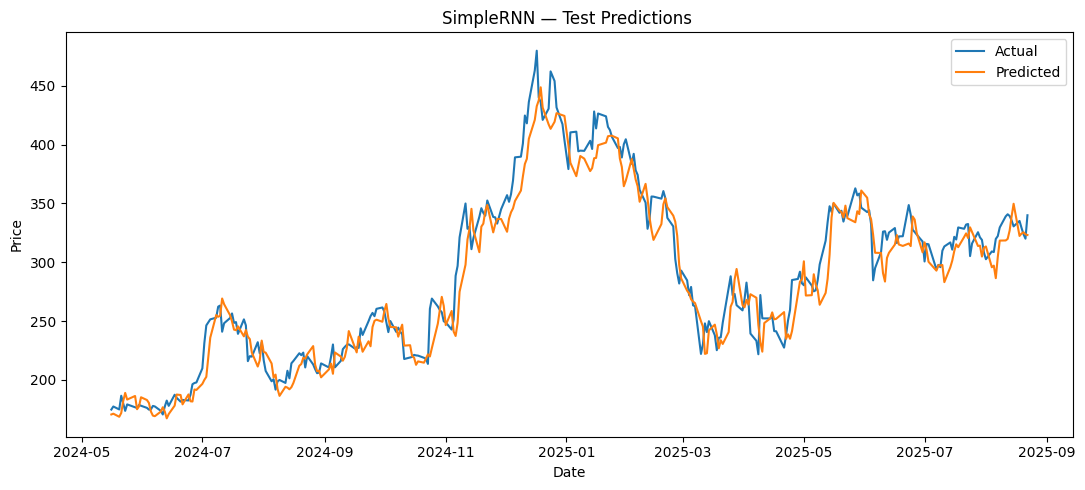

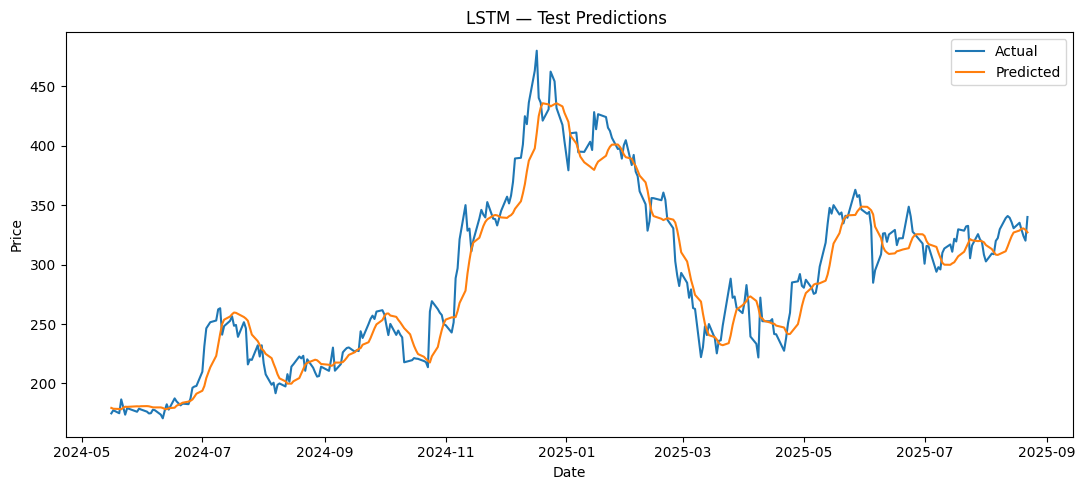

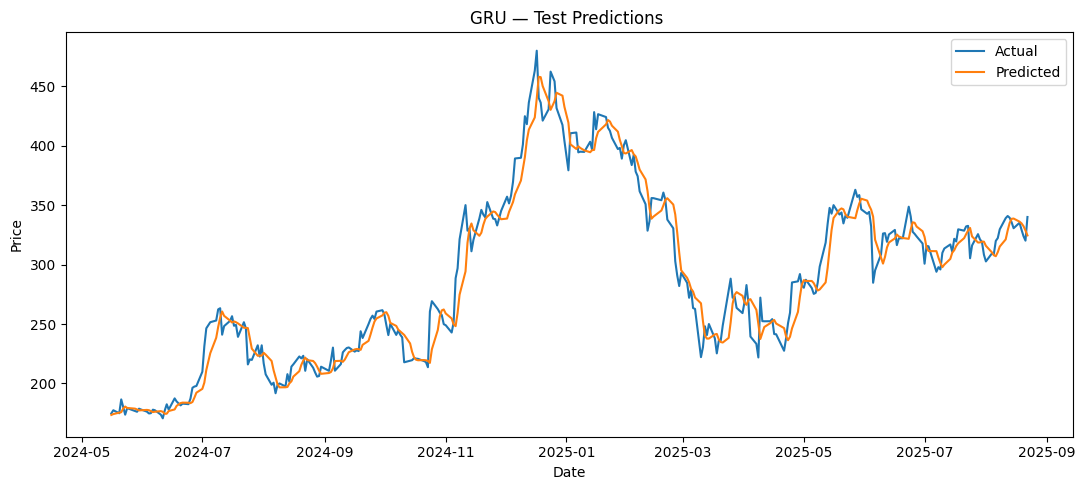

In [ ]:
# filename: run_tesla_rnn.py
import os
import math
import random
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ------------------------------
# Reproducibility
# ------------------------------
def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ------------------------------
# Data utils
# ------------------------------
@dataclass
class SeriesDataset:
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    scaler: MinMaxScaler
    train_index: pd.Index
    val_index: pd.Index
    test_index: pd.Index

def load_prices(ticker: str = "TSLA", period: str = "10y", interval: str = "1d") -> pd.DataFrame:
    """Load OHLCV from yfinance; returns DataFrame with Close column."""
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    df = df.dropna()
    if "Close" not in df.columns:
        raise ValueError("Downloaded data missing 'Close' column.")
    return df

def make_supervised(
    series: np.ndarray, window: int = 60, horizon: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """Turn a 1D series into (X, y) where y is next-step/horizon target."""
    X, y = [], []
    for i in range(window, len(series) - horizon + 1):
        X.append(series[i - window:i])
        y.append(series[i + horizon - 1])
    X = np.array(X)
    y = np.array(y)
    # add feature dimension for RNNs: (samples, timesteps, features)
    X = np.expand_dims(X, axis=-1)
    return X, y

def split_train_val_test(
    values: np.ndarray,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = len(values)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train = values[:n_train]
    val = values[n_train:n_train + n_val]
    test = values[n_train + n_val:]
    return train, val, test

def build_dataset(
    close: pd.Series,
    window: int = 60,
    horizon: int = 1,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15
) -> SeriesDataset:
    """Scale, split, window the series and return ready-to-train tensors plus indices."""
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_all = scaler.fit_transform(close.values.reshape(-1, 1)).flatten()

    train_vals, val_vals, test_vals = split_train_val_test(scaled_all, train_ratio, val_ratio)
    # Keep matching datetime indexes for later plotting
    n = len(close)
    n_train = len(train_vals)
    n_val = len(val_vals)
    idx = close.index
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    # Reconstruct continuous arrays to build windows across each split separately
    X_train, y_train = make_supervised(train_vals, window, horizon)
    X_val, y_val = make_supervised(val_vals, window, horizon)
    X_test, y_test = make_supervised(test_vals, window, horizon)

    # Adjust indices to align with y positions
    # y index starts after 'window' steps in each split
    train_idx_y = train_idx[window:]
    val_idx_y = val_idx[window:]
    test_idx_y = test_idx[window:]

    return SeriesDataset(
        X_train, y_train, X_val, y_val, X_test, y_test, scaler,
        train_idx_y, val_idx_y, test_idx_y
    )

# ------------------------------
# Models registry
# ------------------------------
def rnn_simple(window: int, units: int = 64, dropout: float = 0.1) -> tf.keras.Model:
    m = Sequential([
        SimpleRNN(units, input_shape=(window, 1), return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def rnn_lstm(window: int, units: int = 64, dropout: float = 0.1) -> tf.keras.Model:
    m = Sequential([
        LSTM(units, input_shape=(window, 1), return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def rnn_gru(window: int, units: int = 64, dropout: float = 0.1) -> tf.keras.Model:
    m = Sequential([
        GRU(units, input_shape=(window, 1), return_sequences=False),
        Dropout(dropout),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

ModelBuilder = Callable[[int], tf.keras.Model]

def get_model_zoo(window: int) -> Dict[str, ModelBuilder]:
    """Add or modify entries to experiment with more architectures."""
    return {
        "SimpleRNN": lambda w=window: rnn_simple(w, units=64, dropout=0.1),
        "LSTM":      lambda w=window: rnn_lstm(w, units=96, dropout=0.15),
        "GRU":       lambda w=window: rnn_gru(w, units=96, dropout=0.15),
    }

# ------------------------------
# Training & evaluation
# ------------------------------
@dataclass
class TrainConfig:
    epochs: int = 50
    batch_size: int = 64
    early_stop_patience: int = 7
    reduce_lr_patience: int = 3

def get_callbacks(cfg: TrainConfig) -> List[tf.keras.callbacks.Callback]:
    return [
        EarlyStopping(monitor="val_loss", patience=cfg.early_stop_patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=cfg.reduce_lr_patience)
    ]

def inverse_transform(scaler: MinMaxScaler, arr: np.ndarray) -> np.ndarray:
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

def evaluate_preds(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100.0
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape}

def train_and_evaluate(
    name: str,
    builder: ModelBuilder,
    data: SeriesDataset,
    cfg: TrainConfig,
    window: int
) -> Dict:
    model = builder(window)
    history = model.fit(
        data.X_train, data.y_train,
        validation_data=(data.X_val, data.y_val),
        epochs=cfg.epochs,
        batch_size=cfg.batch_size,
        callbacks=get_callbacks(cfg),
        verbose=0
    )

    # Evaluate on test
    pred_test_scaled = model.predict(data.X_test, verbose=0).flatten()

    # Inverse scale both predictions and ground truth
    y_test = inverse_transform(data.scaler, data.y_test)
    y_pred = inverse_transform(data.scaler, pred_test_scaled)

    metrics = evaluate_preds(y_test, y_pred)

    return {
        "name": name,
        "model": model,
        "history": history.history,
        "y_test": y_test,
        "y_pred": y_pred,
        "test_index": data.test_index,
        "metrics": metrics
    }

# ------------------------------
# Plotting helpers
# ------------------------------
def plot_predictions(result: Dict, title_suffix: str = ""):
    idx = result["test_index"]
    y_true = result["y_test"]
    y_pred = result["y_pred"]

    plt.figure(figsize=(11, 5))
    plt.plot(idx, y_true, label="Actual")
    plt.plot(idx, y_pred, label="Predicted")
    plt.title(f"{result['name']} — Test Predictions {title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_histories(results: List[Dict]):
    plt.figure(figsize=(11, 5))
    for r in results:
        plt.plot(r["history"]["val_loss"], label=f"{r['name']} (val_loss)")
    plt.title("Validation Loss Across Models")
    plt.xlabel("Epoch")
    plt.ylabel("Val Loss (MSE)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------
# Main experiment runner
# ------------------------------
def run_experiment(
    ticker: str = "TSLA",
    period: str = "10y",
    interval: str = "1d",
    window: int = 60,
    horizon: int = 1,
    epochs: int = 50,
    batch_size: int = 64
):
    print(f"Downloading {ticker} ({period}, {interval})...")
    df = load_prices(ticker=ticker, period=period, interval=interval)
    close = df["Close"]

    print("Building dataset...")
    data = build_dataset(close, window=window, horizon=horizon)

    print("Preparing models...")
    zoo = get_model_zoo(window)
    cfg = TrainConfig(epochs=epochs, batch_size=batch_size)

    results = []
    for name, builder in zoo.items():
        print(f"Training {name}...")
        r = train_and_evaluate(name, builder, data, cfg, window)
        results.append(r)

    # Compare metrics
    rows = []
    for r in results:
        m = r["metrics"]
        rows.append({
            "Model": r["name"],
            **{k: round(v, 4) for k, v in m.items()}
        })
    metrics_df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    print("\n=== Test Metrics (lower is better) ===")
    print(metrics_df.to_string(index=False))

    # Plots
    plot_histories(results)
    for r in results:
        plot_predictions(r)

    # Return for programmatic use
    return results, metrics_df

if __name__ == "__main__":
    # Quick knobs to tweak
    results, metrics = run_experiment(
        ticker="TSLA",
        period="10y",
        interval="1d",
        window=60,       # past 60 days to predict next day
        horizon=1,       # 1-step ahead
        epochs=50,
        batch_size=64
    )
